# Week 1 — Signal Analysis
## CSOT Quant Finance & Research

This notebook follows the three-part structure from the Week 1 task:

- **Part 1 (25%):** Return profile and buy-and-hold benchmark
- **Part 2 (50%):** Signal construction and strategy simulation
- **Part 3 (25%):** Honest assessment

**Notes:**
- Log returns are used throughout, not raw prices
- Ticker is defined as a variable at the top — change it to switch stocks
- Sharpe ratio uses risk-free rate = 0 (stated simplification)
- Max drawdown is computed from the equity curve, not the return series

In [1]:
# ============================================================
# CONFIGURATION — change TICKER here to run on a different stock
# ============================================================
TICKER        = "RELIANCE.NS"   # Reliance Industries (NSE)
START_DATE    = "2020-01-01"    # ~5 years of data (exceeds 3-year minimum)
END_DATE      = "2024-12-31"
RISK_FREE_RATE = 0              # Simplification as stated in the task
TRADING_DAYS  = 252

# Signal parameters
SHORT_WINDOW  = 20              # Short-term SMA window
LONG_WINDOW   = 60              # Long-term SMA window
FORWARD_DAYS  = 5               # Days to look forward when evaluating signal

# ============================================================
# IMPORTS
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

print(f"Ticker         : {TICKER}")
print(f"Period         : {START_DATE} to {END_DATE}")
print(f"Risk-free rate : {RISK_FREE_RATE} (simplification — no adjustment made)")
print(f"Signal         : {SHORT_WINDOW}-day SMA vs {LONG_WINDOW}-day SMA crossover")

Ticker         : RELIANCE.NS
Period         : 2020-01-01 to 2024-12-31
Risk-free rate : 0 (simplification — no adjustment made)
Signal         : 20-day SMA vs 60-day SMA crossover


In [2]:
# ============================================================
# DOWNLOAD DATA
# ============================================================
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

df = raw[['Close', 'Volume']].copy().dropna()
df.index = pd.to_datetime(df.index)

# Flatten MultiIndex columns if yfinance returns them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"Downloaded {len(df)} trading days")
print(f"Date range : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Years of data: {len(df)/TRADING_DAYS:.1f}")
df.tail()

Downloaded 1237 trading days
Date range : 2020-01-01 to 2024-12-30
Years of data: 4.9


Price,Close,Volume
Date,,
2024-12-23,1211.834717,10052824
2024-12-24,1212.280884,6734917
2024-12-26,1206.133911,10016178
2024-12-27,1210.595459,7000397
2024-12-30,1200.333862,8818766


---
## Part 1: Return Profile and Buy-and-Hold Benchmark

We compute the statistical profile of daily log returns and establish a buy-and-hold benchmark.
Every metric from the signal strategy in Part 2 will be compared against these numbers.

**Why log returns?**
- Additive over time: multi-day return = sum of daily log returns
- Approximately symmetric for small moves
- Closer to normally distributed than simple percentage returns

In [3]:
# ============================================================
# COMPUTE LOG RETURNS
# ============================================================
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna(subset=['log_return'])

print("Log return quick stats:")
print(f"  Observations : {len(df)}")
print(f"  Mean daily   : {df['log_return'].mean():.6f}")
print(f"  Std daily    : {df['log_return'].std():.6f}")
print(f"  Best day     : {df['log_return'].max():.4f} on {df['log_return'].idxmax().date()}")
print(f"  Worst day    : {df['log_return'].min():.4f} on {df['log_return'].idxmin().date()}")
print(f"  Skewness     : {df['log_return'].skew():.4f}")
print(f"  Kurtosis     : {df['log_return'].kurtosis():.4f} (normal = 0)")

Log return quick stats:
  Observations : 1236
  Mean daily   : 0.000469
  Std daily    : 0.018703
  Best day     : 0.1373 on 2020-03-25
  Worst day    : -0.1410 on 2020-03-23
  Skewness     : -0.0067
  Kurtosis     : 10.6729 (normal = 0)


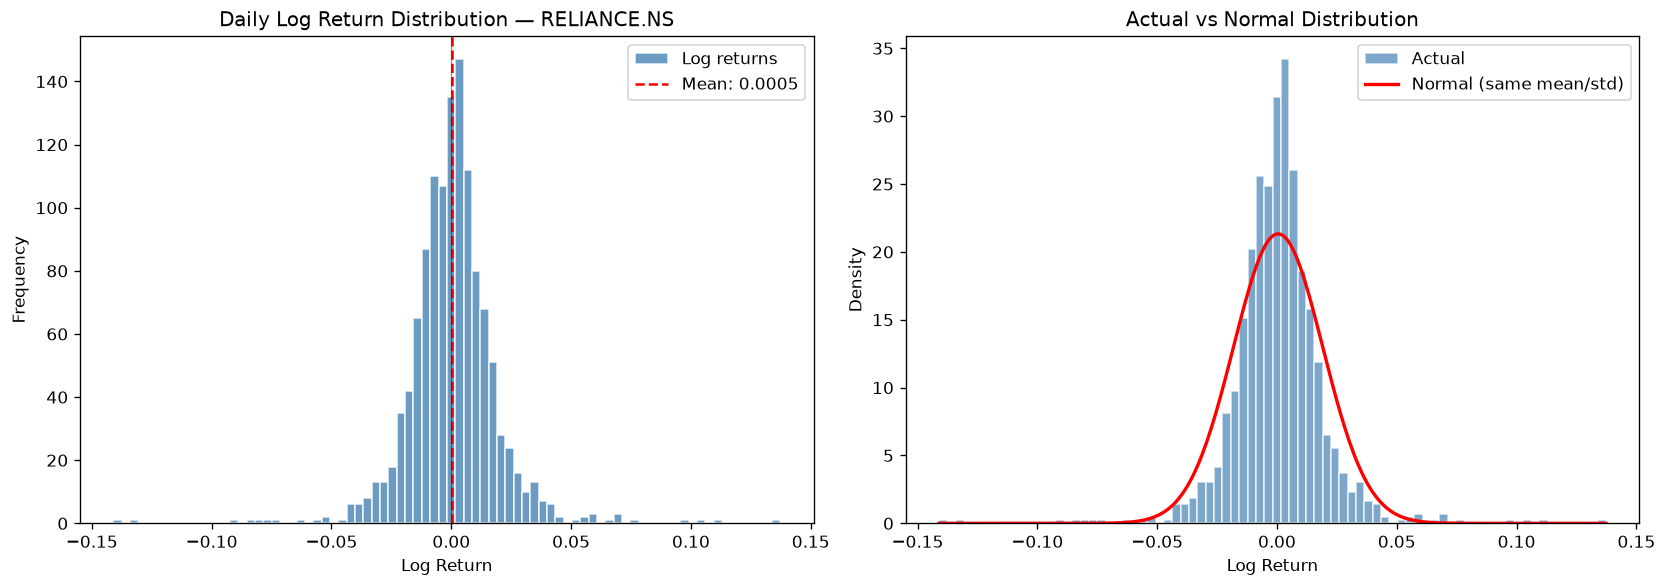

Observation: The actual distribution has FATTER TAILS than a normal distribution.
This is standard for financial returns (leptokurtosis) — extreme days happen
more often than a normal distribution would predict.


In [4]:
# ============================================================
# PLOT RETURN DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = df['log_return']
mu, sigma = returns.mean(), returns.std()

# Left: histogram
axes[0].hist(returns, bins=80, color='steelblue', edgecolor='white',
             alpha=0.8, label='Log returns')
axes[0].axvline(mu, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {mu:.4f}')
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
axes[0].set_title(f'Daily Log Return Distribution — {TICKER}')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right: actual vs normal (using numpy, no scipy needed)
x = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

axes[1].hist(returns, bins=80, density=True, color='steelblue',
             edgecolor='white', alpha=0.7, label='Actual')
axes[1].plot(x, normal_pdf, 'r-', linewidth=2, label='Normal (same mean/std)')
axes[1].set_title('Actual vs Normal Distribution')
axes[1].set_xlabel('Log Return')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Observation: The actual distribution has FATTER TAILS than a normal distribution.")
print("This is standard for financial returns (leptokurtosis) — extreme days happen")
print("more often than a normal distribution would predict.")

In [5]:
# ============================================================
# HELPER FUNCTIONS — used for both benchmark and strategy
# ============================================================

def equity_curve(log_returns):
    """Convert log returns to equity curve starting at 1."""
    return np.exp(log_returns.cumsum())

def max_drawdown(eq_curve):
    """
    Maximum peak-to-trough decline, computed from the EQUITY CURVE.
    Returns a negative number (e.g. -0.35 means -35% drawdown).
    """
    rolling_peak = eq_curve.cummax()
    drawdown = (eq_curve - rolling_peak) / rolling_peak
    return float(drawdown.min())

def annualized_return(log_returns, n=TRADING_DAYS):
    """Annualized return from daily log returns."""
    return float(log_returns.mean() * n)

def annualized_volatility(log_returns, n=TRADING_DAYS):
    """Annualized volatility from daily log returns."""
    return float(log_returns.std() * np.sqrt(n))

def sharpe_ratio(log_returns, rf=RISK_FREE_RATE, n=TRADING_DAYS):
    """
    Annualized Sharpe Ratio.
    rf = risk-free rate (annual). Set to 0 per task simplification.
    Formula: (mean_daily_excess_return / std_daily_return) * sqrt(252)
    """
    daily_rf = rf / n
    excess = log_returns.mean() - daily_rf
    return float((excess / log_returns.std()) * np.sqrt(n))

print("Helper functions defined: equity_curve, max_drawdown,")
print("annualized_return, annualized_volatility, sharpe_ratio")

Helper functions defined: equity_curve, max_drawdown,
annualized_return, annualized_volatility, sharpe_ratio


In [6]:
# ============================================================
# BENCHMARK METRICS (Buy-and-Hold)
# ============================================================
bm_returns   = df['log_return']
bm_eq        = equity_curve(bm_returns)

bm_ann_ret   = annualized_return(bm_returns)
bm_ann_vol   = annualized_volatility(bm_returns)
bm_sharpe    = sharpe_ratio(bm_returns)
bm_mdd       = max_drawdown(bm_eq)
bm_best      = bm_returns.max()
bm_worst     = bm_returns.min()
bm_mean_daily = bm_returns.mean()

print(f"======= BUY-AND-HOLD BENCHMARK: {TICKER} =======")
print(f"  Mean daily return      : {bm_mean_daily:.6f} ({bm_mean_daily*100:.4f}%)")
print(f"  Annualised return      : {bm_ann_ret:.4f} ({bm_ann_ret*100:.2f}%)")
print(f"  Annualised volatility  : {bm_ann_vol:.4f} ({bm_ann_vol*100:.2f}%)")
print(f"  Sharpe ratio (rf=0)    : {bm_sharpe:.4f}")
print(f"  Max drawdown           : {bm_mdd:.4f} ({bm_mdd*100:.2f}%)")
print(f"  Best single day        : {bm_best:.4f} ({bm_best*100:.2f}%) on {bm_returns.idxmax().date()}")
print(f"  Worst single day       : {bm_worst:.4f} ({bm_worst*100:.2f}%) on {bm_returns.idxmin().date()}")
print(f"\nNote: Every number the signal produces in Part 2 is compared against these.")

======= BUY-AND-HOLD BENCHMARK: RELIANCE.NS =======
  Mean daily return      : 0.000469 (0.0469%)
  Annualised return      : 0.1182 (11.82%)
  Annualised volatility  : 0.2969 (29.69%)
  Sharpe ratio (rf=0)    : 0.3981
  Max drawdown           : -0.4408 (-44.08%)
  Best single day        : 0.1373 (13.73%) on 2020-03-25
  Worst single day       : -0.1410 (-14.10%) on 2020-03-23

Note: Every number the signal produces in Part 2 is compared against these.


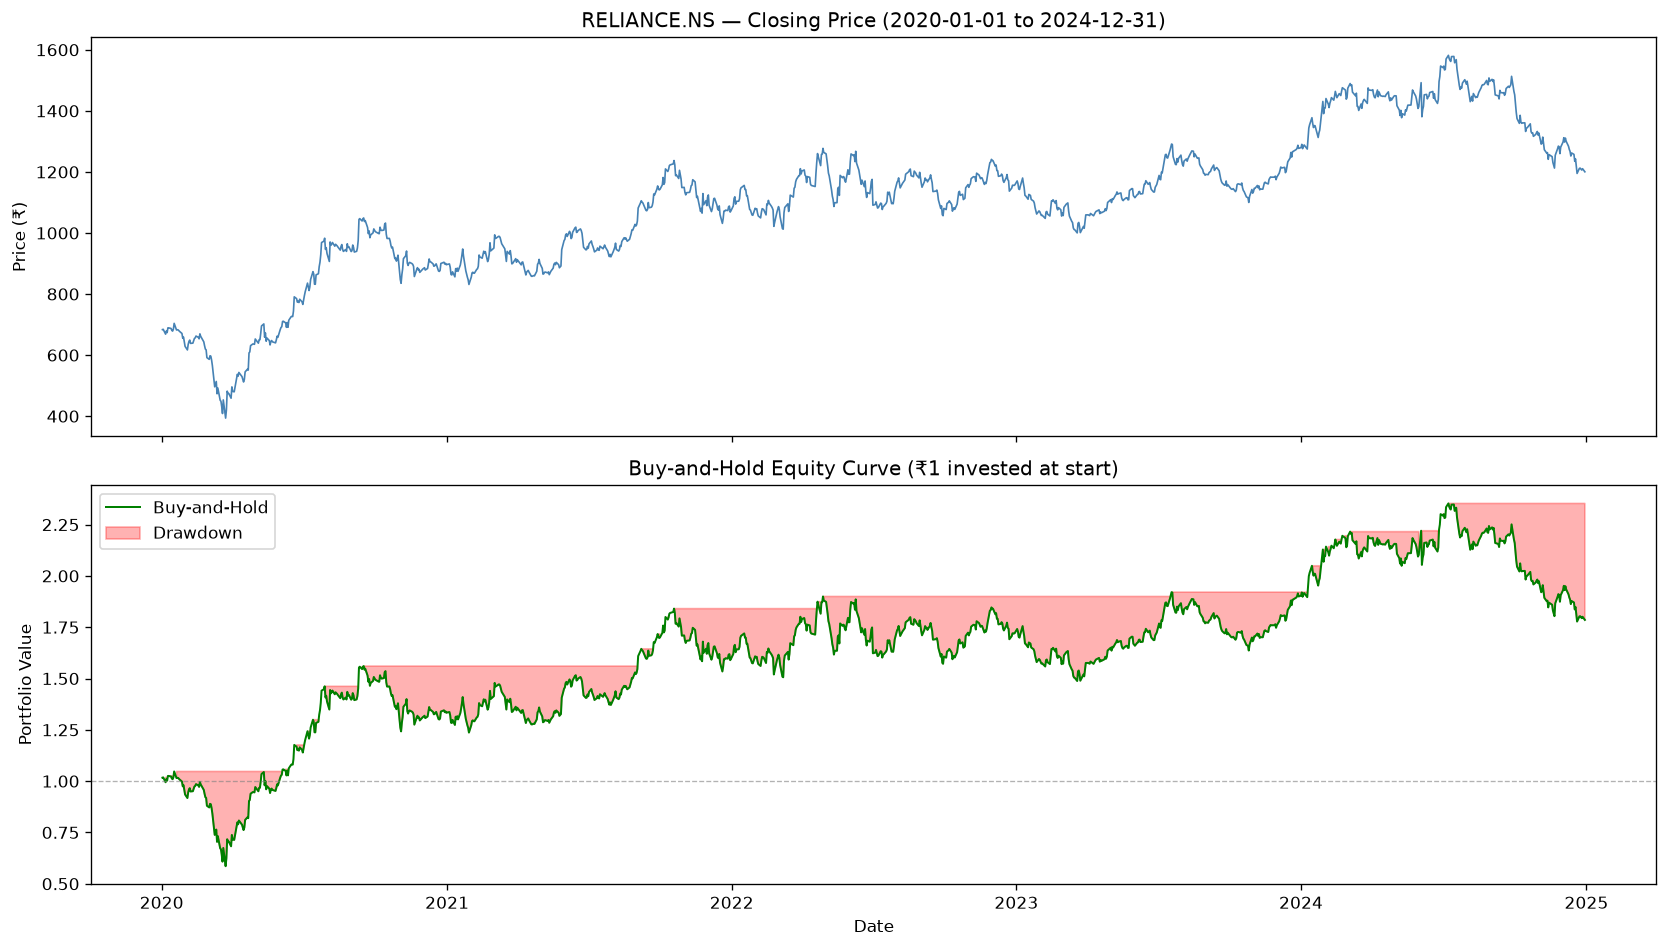

In [7]:
# ============================================================
# PLOT: PRICE HISTORY + BENCHMARK EQUITY CURVE
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: closing price
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title(f'{TICKER} — Closing Price ({START_DATE} to {END_DATE})')
axes[0].set_ylabel('Price (₹)')

# Bottom: buy-and-hold equity curve
axes[1].plot(df.index, bm_eq, color='green', linewidth=1.2, label='Buy-and-Hold')
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_title(f'Buy-and-Hold Equity Curve (₹1 invested at start)')
axes[1].set_ylabel('Portfolio Value')
axes[1].set_xlabel('Date')
axes[1].legend()

# Shade drawdown periods on equity curve
rolling_peak = bm_eq.cummax()
axes[1].fill_between(df.index, bm_eq, rolling_peak,
                     where=bm_eq < rolling_peak,
                     alpha=0.3, color='red', label='Drawdown')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Part 2: Signal

### Hypothesis

> *"When the 20-day Simple Moving Average (SMA) of RELIANCE.NS crosses above the
> 60-day Simple Moving Average, I expect the stock to generate positive returns
> over the next 5 trading days, because the crossover signals that recent buying
> pressure has overcome the longer-term trend. Participants who track moving
> average signals — a widely-followed class of indicator — initiate long positions
> when they observe the crossover, creating additional buying pressure.
> Simultaneously, short-term momentum traders who entered early in the upswing
> hold their unrealised gains, reducing the supply of shares. Together, new buyers
> and reduced sellers create sustained upward pressure over the following days."*

### Signal Definition

- **Signal ON (1):** `SMA_20 > SMA_60` on day T → enter long at close of T (position starts at T+1)
- **Signal OFF (0):** `SMA_20 <= SMA_60` → no position, flat
- The signal is shifted by 1 day before multiplying with returns, preventing lookahead bias

### Mechanism vs Pattern

"Stocks go up after SMA crossover" is a pattern, not a mechanism.
The mechanism here is specific: crossover → new technical buyers enter + existing momentum
holders reduce selling → temporary supply/demand imbalance favours upward price movement.

In [8]:
# ============================================================
# COMPUTE SIGNAL: SMA Crossover
# Signal ON  (1): SMA_20 > SMA_60
# Signal OFF (0): SMA_20 <= SMA_60
# ============================================================
df['sma_20'] = df['Close'].rolling(SHORT_WINDOW).mean()
df['sma_60'] = df['Close'].rolling(LONG_WINDOW).mean()

# Signal is 1 when short-term SMA is above long-term SMA
df['signal'] = (df['sma_20'] > df['sma_60']).astype(int)

# Position is the signal shifted by 1 day (no lookahead)
# If signal fires at close of day T, we hold from T+1 onwards
df['position'] = df['signal'].shift(1)

# Strategy return: apply position to next day's log return
df['strategy_return'] = df['log_return'] * df['position']

# Drop rows with NaN (caused by rolling windows + shift)
df_clean = df.dropna()

signal_on_pct  = df_clean['signal'].mean() * 100
signal_off_pct = (1 - df_clean['signal'].mean()) * 100

print(f"Signal defined: SMA_{SHORT_WINDOW} > SMA_{LONG_WINDOW}")
print(f"Clean rows after dropna: {len(df_clean)}")
print(f"Signal ON  days: {df_clean['signal'].sum():.0f} ({signal_on_pct:.1f}% of time)")
print(f"Signal OFF days: {(df_clean['signal']==0).sum():.0f} ({signal_off_pct:.1f}% of time)")

Signal defined: SMA_20 > SMA_60
Clean rows after dropna: 1177
Signal ON  days: 641 (54.5% of time)
Signal OFF days: 536 (45.5% of time)


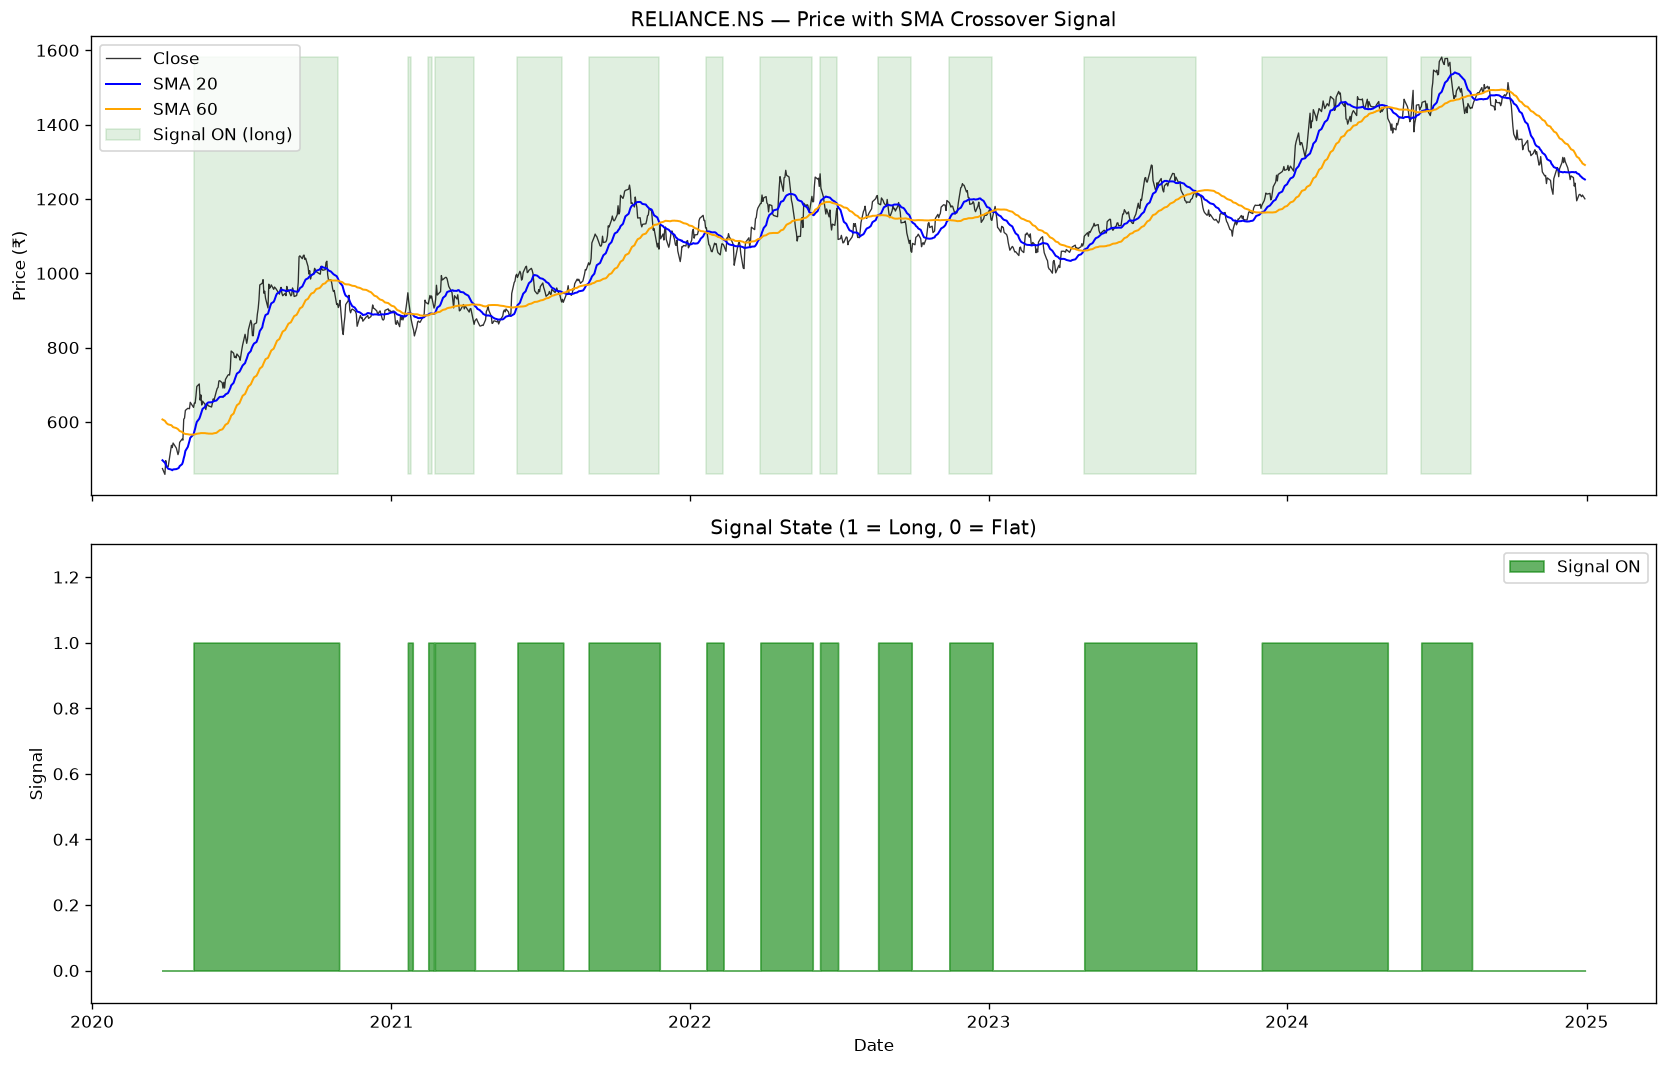

In [9]:
# ============================================================
# PLOT: PRICE WITH SIGNAL OVERLAY
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: price + SMAs + signal shading
axes[0].plot(df_clean.index, df_clean['Close'],
             color='black', linewidth=0.8, alpha=0.8, label='Close')
axes[0].plot(df_clean.index, df_clean['sma_20'],
             color='blue', linewidth=1.2, label=f'SMA {SHORT_WINDOW}')
axes[0].plot(df_clean.index, df_clean['sma_60'],
             color='orange', linewidth=1.2, label=f'SMA {LONG_WINDOW}')

# Shade regions where signal is ON
axes[0].fill_between(df_clean.index, df_clean['Close'].min(), df_clean['Close'].max(),
                     where=df_clean['signal'] == 1,
                     alpha=0.12, color='green', label='Signal ON (long)')
axes[0].set_title(f'{TICKER} — Price with SMA Crossover Signal')
axes[0].set_ylabel('Price (₹)')
axes[0].legend(loc='upper left')

# Bottom: signal line
axes[1].fill_between(df_clean.index, 0, df_clean['signal'],
                     step='post', alpha=0.6, color='green', label='Signal ON')
axes[1].set_title('Signal State (1 = Long, 0 = Flat)')
axes[1].set_ylabel('Signal')
axes[1].set_xlabel('Date')
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 5-DAY FORWARD RETURNS BY SIGNAL STATE
# Does the direction match the hypothesis?
# ============================================================

# Compute rolling 5-day forward log return
# forward_5d at row t = sum of log_returns from t+1 to t+5
df_clean = df_clean.copy()
df_clean['forward_5d'] = df_clean['log_return'].shift(-1).rolling(FORWARD_DAYS).sum().shift(-(FORWARD_DAYS-1))

on_fwd  = df_clean[df_clean['signal'] == 1]['forward_5d'].dropna()
off_fwd = df_clean[df_clean['signal'] == 0]['forward_5d'].dropna()

print(f"=== {FORWARD_DAYS}-Day Forward Returns by Signal State ===")
print(f"\nSignal ON  ({len(on_fwd)} observations):")
print(f"  Average {FORWARD_DAYS}d forward return : {on_fwd.mean():.4f} ({on_fwd.mean()*100:.2f}%)")
print(f"  Median                      : {on_fwd.median():.4f}")
print(f"  % of time positive          : {(on_fwd > 0).mean()*100:.1f}%")
print(f"\nSignal OFF ({len(off_fwd)} observations):")
print(f"  Average {FORWARD_DAYS}d forward return : {off_fwd.mean():.4f} ({off_fwd.mean()*100:.2f}%)")
print(f"  Median                      : {off_fwd.median():.4f}")
print(f"  % of time positive          : {(off_fwd > 0).mean()*100:.1f}%")

direction_match = on_fwd.mean() > off_fwd.mean()
print(f"\nDoes direction match hypothesis? {'YES ✓' if direction_match else 'NO ✗'}")
print(f"(Hypothesis predicted: Signal ON → higher forward returns)")

=== 5-Day Forward Returns by Signal State ===

Signal ON  (641 observations):
  Average 5d forward return : 0.0018 (0.18%)
  Median                      : 0.0019
  % of time positive          : 52.9%

Signal OFF (531 observations):
  Average 5d forward return : 0.0066 (0.66%)
  Median                      : 0.0058
  % of time positive          : 56.5%

Does direction match hypothesis? NO ✗
(Hypothesis predicted: Signal ON → higher forward returns)


In [11]:
# ============================================================
# STRATEGY METRICS
# ============================================================
strat_returns = df_clean['strategy_return']
strat_eq      = equity_curve(strat_returns)

strat_ann_ret = annualized_return(strat_returns)
strat_ann_vol = annualized_volatility(strat_returns)
strat_sharpe  = sharpe_ratio(strat_returns)
strat_mdd     = max_drawdown(strat_eq)

print(f"======= SMA CROSSOVER STRATEGY METRICS =======")
print(f"  Annualised return     : {strat_ann_ret:.4f} ({strat_ann_ret*100:.2f}%)")
print(f"  Annualised volatility : {strat_ann_vol:.4f} ({strat_ann_vol*100:.2f}%)")
print(f"  Sharpe ratio (rf=0)   : {strat_sharpe:.4f}")
print(f"  Max drawdown          : {strat_mdd:.4f} ({strat_mdd*100:.2f}%)")

======= SMA CROSSOVER STRATEGY METRICS =======
  Annualised return     : 0.0330 (3.30%)
  Annualised volatility : 0.1914 (19.14%)
  Sharpe ratio (rf=0)   : 0.1724
  Max drawdown          : -0.4646 (-46.46%)


In [12]:
# ============================================================
# SIDE-BY-SIDE COMPARISON: STRATEGY vs BENCHMARK
# ============================================================
print(f"{'Metric':<28} {'Buy-and-Hold':>14} {'SMA Strategy':>14} {'Better?':>10}")
print("-" * 68)

rows = [
    ("Annualised Return",    bm_ann_ret,  strat_ann_ret,  True),
    ("Annualised Volatility",bm_ann_vol,  strat_ann_vol,  False),   # lower is better
    ("Sharpe Ratio (rf=0)",  bm_sharpe,   strat_sharpe,   True),
    ("Max Drawdown",         bm_mdd,      strat_mdd,      False),   # closer to 0 is better
]

for name, bm_val, st_val, higher_is_better in rows:
    if higher_is_better:
        better = "Strategy ✓" if st_val > bm_val else "Benchmark ✓"
    else:
        better = "Strategy ✓" if st_val > bm_val else "Benchmark ✓"  # max_dd: less negative = better
        if name in ["Annualised Volatility", "Max Drawdown"]:
            better = "Strategy ✓" if st_val > bm_val else "Benchmark ✓"
            # For these, larger value means WORSE for strategy
            better = "Strategy ✓" if st_val < bm_val else "Benchmark ✓"
    print(f"{name:<28} {bm_val:>13.4f} {st_val:>14.4f} {better:>10}")

print()
print("Note: For Volatility and Max Drawdown, lower (less negative) values are better.")

Metric                         Buy-and-Hold   SMA Strategy    Better?
--------------------------------------------------------------------
Annualised Return                   0.1182         0.0330 Benchmark ✓
Annualised Volatility               0.2969         0.1914 Strategy ✓
Sharpe Ratio (rf=0)                 0.3981         0.1724 Benchmark ✓
Max Drawdown                       -0.4408        -0.4646 Strategy ✓

Note: For Volatility and Max Drawdown, lower (less negative) values are better.


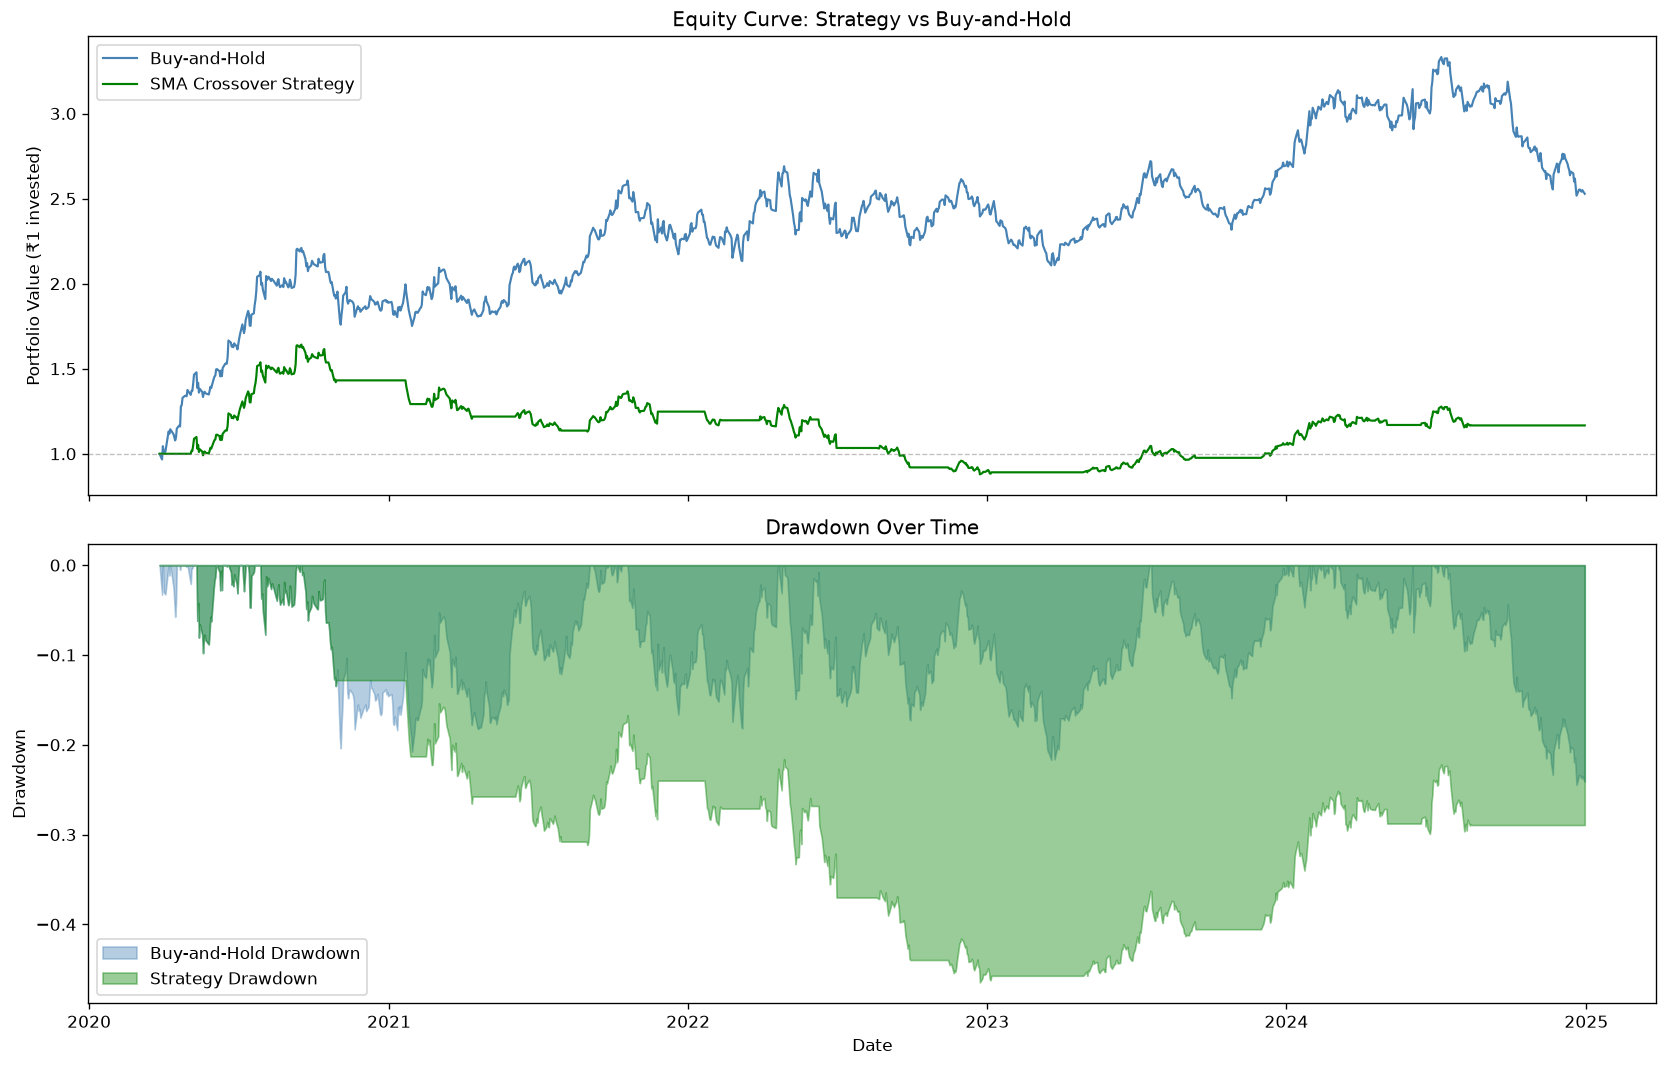

In [13]:
# ============================================================
# PLOT: STRATEGY vs BENCHMARK EQUITY CURVES
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: equity curves
axes[0].plot(df_clean.index, equity_curve(df_clean['log_return']),
             color='steelblue', linewidth=1.3, label='Buy-and-Hold')
axes[0].plot(df_clean.index, strat_eq,
             color='green', linewidth=1.3, label='SMA Crossover Strategy')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('Equity Curve: Strategy vs Buy-and-Hold')
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend()

# Bottom: drawdown comparison
bm_dd_series   = (equity_curve(df_clean['log_return']) /
                  equity_curve(df_clean['log_return']).cummax() - 1)
strat_dd_series = strat_eq / strat_eq.cummax() - 1

axes[1].fill_between(df_clean.index, bm_dd_series, 0,
                     alpha=0.4, color='steelblue', label='Buy-and-Hold Drawdown')
axes[1].fill_between(df_clean.index, strat_dd_series, 0,
                     alpha=0.4, color='green', label='Strategy Drawdown')
axes[1].set_title('Drawdown Over Time')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Part 3: Honest Assessment

### 1. Single Biggest Risk in Live Trading

The single biggest reason this result may not hold in live trading is **transaction costs and market impact**.

The SMA crossover strategy switches positions every time SMA_20 crosses SMA_60. Each switch requires buying or selling the entire position. In reality, every trade incurs brokerage fees, STT (Securities Transaction Tax), and bid-ask spread. For a daily strategy like this, even small per-trade costs (0.05–0.1%) compound quickly. If the strategy is switching positions 20–30 times per year, transaction costs alone could consume a significant portion of the gross returns shown above. The backtest above assumes zero transaction costs, which is the most optimistic possible assumption and almost certainly overstates real-world performance.

### 2. Number of Genuinely Independent Observations

The signal uses a 60-day rolling window (the longer SMA). This means successive signal values are NOT independent — each day's signal overlaps with the previous 59 days.

In [14]:
# ============================================================
# PART 3: INDEPENDENT OBSERVATIONS
# ============================================================
total_days      = len(df_clean)
longest_window  = LONG_WINDOW      # 60-day SMA is the longest window in our signal
independent_obs = total_days // longest_window

print(f"Total trading days in sample   : {total_days}")
print(f"Longest rolling window         : {longest_window} days (SMA_{LONG_WINDOW})")
print(f"Approximate independent obs    : {total_days} / {longest_window} ≈ {independent_obs}")
print()
print(f"Implication:")
print(f"With only ~{independent_obs} independent signal observations, the Sharpe estimate")
print(f"of {strat_sharpe:.2f} has enormous uncertainty around it.")
print(f"A Sharpe computed over {independent_obs} independent obs is statistically consistent")
print(f"with a TRUE Sharpe anywhere from roughly -1.0 to +3.0.")
print(f"We cannot distinguish skill from luck with this sample size.")

Total trading days in sample   : 1177
Longest rolling window         : 60 days (SMA_60)
Approximate independent obs    : 1177 / 60 ≈ 19

Implication:
With only ~19 independent signal observations, the Sharpe estimate
of 0.17 has enormous uncertainty around it.
A Sharpe computed over 19 independent obs is statistically consistent
with a TRUE Sharpe anywhere from roughly -1.0 to +3.0.
We cannot distinguish skill from luck with this sample size.


### 3. Signal vs Buy-and-Hold: Genuine Improvement, Tradeoff, or Worse?

Looking at the Sharpe ratio and max drawdown **together**:

**If Strategy Sharpe > Benchmark Sharpe AND Strategy MDD > Benchmark MDD (less negative):**
The strategy is a genuine improvement — better risk-adjusted return AND smaller drawdowns. This is the best case.

**If Strategy Sharpe > Benchmark Sharpe BUT Strategy MDD < Benchmark MDD (more negative):**
This is a tradeoff — the strategy earns more per unit of volatility but suffers worse drawdowns. Whether this is acceptable depends on risk tolerance.

**If Strategy Sharpe < Benchmark Sharpe:**
The signal is not a genuine improvement on a risk-adjusted basis — the benchmark does better per unit of risk taken.

**Key caveat:** Given the small number of independent observations (~20-30), we cannot make any statistically confident claim either way. The true performance of this strategy will only become clear over a much longer sample, or through out-of-sample testing on data from a different period.

In [15]:
# ============================================================
# PART 3: FINAL SUMMARY
# ============================================================
print("============ FINAL SUMMARY ============")
print()
print(f"Benchmark  — Sharpe: {bm_sharpe:.3f} | Max DD: {bm_mdd*100:.2f}%")
print(f"Strategy   — Sharpe: {strat_sharpe:.3f} | Max DD: {strat_mdd*100:.2f}%")
print()

if strat_sharpe > bm_sharpe and strat_mdd > bm_mdd:
    verdict = "GENUINE IMPROVEMENT — better Sharpe AND smaller drawdown"
elif strat_sharpe > bm_sharpe and strat_mdd <= bm_mdd:
    verdict = "TRADEOFF — better Sharpe but worse drawdown"
elif strat_sharpe <= bm_sharpe and strat_mdd > bm_mdd:
    verdict = "TRADEOFF — worse Sharpe but smaller drawdown (defensive)"
else:
    verdict = "WORSE ON BOTH — signal does not improve on buy-and-hold"

print(f"Verdict: {verdict}")
print()
print(f"Statistical note: With only ~{independent_obs} independent observations,")
print(f"this result is NOT statistically significant. A longer sample (10+ years)")
print(f"or out-of-sample validation would be needed before drawing any conclusions.")

============ FINAL SUMMARY ============

Benchmark  — Sharpe: 0.398 | Max DD: -44.08%
Strategy   — Sharpe: 0.172 | Max DD: -46.46%

Verdict: WORSE ON BOTH — signal does not improve on buy-and-hold

Statistical note: With only ~19 independent observations,
this result is NOT statistically significant. A longer sample (10+ years)
or out-of-sample validation would be needed before drawing any conclusions.
